# Heart Disease Prediction
## Author [M. ARSALAN AKHTAR](https://github.com/git-arsalan/01_ML_Project_HeartDisease)
### Date:07-11-2026
### Dataset:[Heart Disease UCI Data](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?resource=download)



## Meta Data About Dataset

### Context
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

### Content
#### Column Descriptions:
* 'id' (Unique id for each patient)
* 'age' (Age of the patient in years)
* 'origin' (place of study)
* 'sex' (Male/Female)
* 'cp' chest pain type 
    1. typical angina 
    2. atypical angina
    3. non-anginal 
    4. asymptomatic
* 'trestbps' resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* 'chol' (serum cholesterol in mg/dl)
* 'fbs' (if fasting blood sugar > 120 mg/dl)
* 'restecg' (resting electrocardiographic results)
* -- 'Values': [normal, stt abnormality, lv hypertrophy]
* 'thalach': maximum heart rate achieved
* 'exang': exercise-induced angina (True/ False)
* 'oldpeak': ST depression induced by exercise relative to rest
* 'slope': the slope of the peak exercise ST segment
* 'ca': number of major vessels (0-3) colored by fluoroscopy
* 'thal': [normal; fixed defect; reversible defect]
* 'num': the predicted attribute

### Acknowledgements
#### Creators:
* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.
#### Relevant Papers:
* Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
#### Web Link
* David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database." Web Link
* Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61. Web Link
#### Citation Request:
* The authors of the databases have requested that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution. They would be:

* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.

## Aims and Objectives:
we will Update it after doing EDA


## Importing Necessary Libraries:
Now importing libraries needed to start the project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer,KNNImputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Machine Learning Lib
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score
# for classification task
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# ignore warnings
import warnings
warnings.filterwarnings('ignore')




## Loading Data Set

In [2]:
Hd_df = pd.read_csv('../01Dataset/heart_disease_uci.csv')
Hd_df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Exploratory Data Analysis (EDA)
### Now we will explore each column


In [3]:
# Now we will explore the datatype of each column
Hd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
# Now checking the shape of data
Hd_df.shape

(920, 16)

## Data Contains 920 Rows and 16 Columns

In [5]:
# also verifiying it with id Column
Hd_df['id'].min() , Hd_df['id'].max()

(np.int64(1), np.int64(920))

In [6]:
# Now exploring the age column
Hd_df['age'].min() , Hd_df['age'].max()

(np.int64(28), np.int64(77))

## Age Group for the dataset
### Here we can validate that Dataset Collected the data for Age group from 28 yrs to 77 yrs

<Axes: xlabel='age', ylabel='Count'>

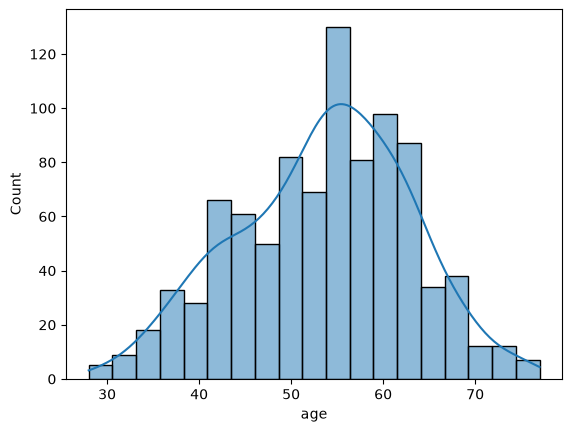

In [7]:
# NOW we draw histogram to visualize the distribution of age column
sns.histplot(Hd_df['age'],kde=True)

Mean=53.51086956521739
Mode=54
Mode=54.0


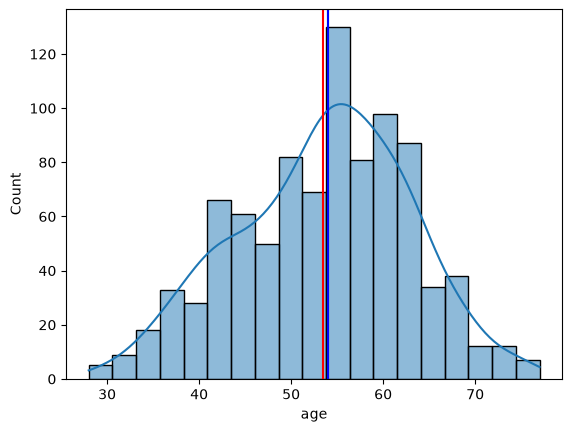

In [8]:
sns.histplot(Hd_df['age'],kde=True)
plt.axvline(Hd_df['age'].mean(), color='red') # getting mean line on hist plot
plt.axvline(Hd_df['age'].mode()[0], color='green') # getting mode line on hist plot
plt.axvline(Hd_df['age'].median(), color='blue') # getting medina line on hist plot

print(f"Mean={Hd_df['age'].mean()}")
print(f"Mode={Hd_df['age'].mode()[0]}")
print(f"Mode={Hd_df['age'].median()}")


#### Lets explore the Gender based distribution of heart column

In [9]:
# now we ploting the age column using plotly and differentiate it different color according to sex column
fig = px.histogram(data_frame=Hd_df, x='age', color='sex')
fig.show()

In [10]:
# find the value of sex column
Hd_df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [11]:
# calculate the percentage of male and female value counts
male_count = 726
female_count = 194
total_count = male_count + female_count
# now calculate percentage
male_per = (male_count / total_count) * 100
female_per = (female_count/total_count) * 100
print(f"Male percentage in Data ={male_per:.2f}%")
print(f"Female percentage in Data={female_per:.2f}%")

# difference percentage
diff_per = ((male_count-female_count)/(female_count))*100
print(f"Males are {diff_per:.2f}% more than females")

Male percentage in Data =78.91%
Female percentage in Data=21.09%
Males are 274.23% more than females


In [12]:
# now find the count of age column group by sex column
Hd_df.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    71      2
        31      1
        28      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [13]:
# Now lets deal with dataset column
# find the value counts of dataset column
Hd_df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [14]:
# now we will visualize the dataset column using countplot of seaborn

#sns.countplot(x='dataset', data=Hd_df , hue='sex')

# Now we will visualize the dataset column using plotly express
px.bar(data_frame=Hd_df, x='dataset', color='sex')

In [15]:
# now print the count of dataset column group by sex column
Hd_df.groupby('sex')['dataset'].value_counts()

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64

In [16]:
# make a plot of age column using plotly express and differentiate it with dataset column
px.histogram(data_frame=Hd_df, x='age', color='dataset')

In [17]:
# print mean, median and mode of age column group by dataset column
summary = Hd_df.groupby('dataset')['age'].agg(
    Mean='mean',
    Median='median',
    Mode=lambda x: x.mode().tolist()
)

print(summary)

                    Mean  Median      Mode
dataset                                   
Cleveland      54.351974    55.5      [58]
Hungary        47.894198    49.0      [54]
Switzerland    55.317073    56.0      [61]
VA Long Beach  59.350000    60.0  [62, 63]


#### Now Lets Explore CP (CHEST PAIN) column


In [18]:
# value count of chest_pain_type column
chest_pain_value_counts = Hd_df['cp'].value_counts()
print(chest_pain_value_counts)

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64


In [19]:
# count plot of cp column group by sex column
fig = px.histogram(data_frame=Hd_df, x='cp', color='sex', barmode='group', title='Chest Pain Type Distribution by Sex')
fig.show()

In [20]:
# count plot of chest_pain_type column group by dataset column
fig = px.histogram(data_frame=Hd_df, x='cp', color='dataset', barmode='group', title='Chest Pain Type Distribution by Dataset')
fig.show()

In [21]:
# draw a plot of age column group by chest_pain_type column using plotly
#import plotly.express as px

fig = px.histogram(data_frame=Hd_df, x='age', color='cp', barmode='group', title='Age Distribution by Chest Pain Type')
fig.show()

#### Now Lets explore the trestbps column


##### The column trestbps stands for resting blood pressure (in mm Hg) measured at hospital admission.
##### The normal resting bps is 120 80 mm/Hg 

In [22]:
Hd_df['trestbps'].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

<Axes: xlabel='trestbps', ylabel='Count'>

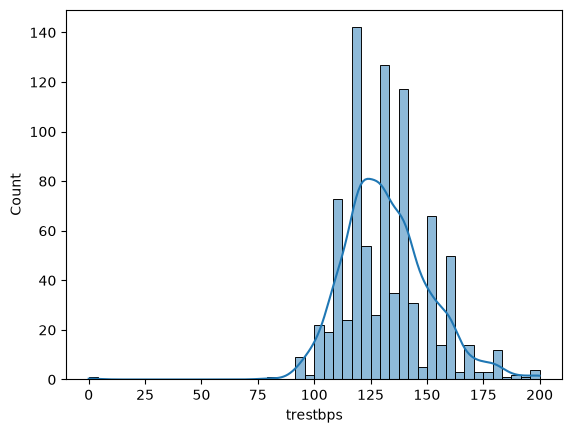

In [23]:
# Now we will visualize the trestbps column using histplot
sns.histplot(Hd_df['trestbps'], kde=True)

In [24]:
# Deal with missing values in the trestbps column using SimpleImputer
# first find the percentage of missing values in the trestbps column
per_trestbps = Hd_df['trestbps'].isnull().sum() / Hd_df['trestbps'].shape[0] * 100
print(f"Percentage of missing values in 'trestbps' column: {per_trestbps:.2f}%")


Percentage of missing values in 'trestbps' column: 6.41%


In [26]:
# now impute the missing values in the trestbps column using iterative imputer
imputer = IterativeImputer(max_iter=10, random_state=42)
Hd_df['trestbps'] = imputer.fit_transform(Hd_df[['trestbps']])

# Now check the percentage of missing values in the trestbps column after imputation
per_trestbps_after = Hd_df['trestbps'].isnull().sum() / Hd_df['trestbps'].shape[0] * 100
print(f"Percentage of missing values in 'trestbps' column after imputation: {per_trestbps_after:.2f}%")

Percentage of missing values in 'trestbps' column after imputation: 0.00%


In [29]:
# now lets impute other columns with missing values using iterative imputer
#print("Columns with missing values before imputation:")
(Hd_df.isnull().sum() / Hd_df.shape[0] * 100).sort_values(ascending=False)

ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
thalch       5.978261
exang        5.978261
chol         3.260870
restecg      0.217391
trestbps     0.000000
cp           0.000000
dataset      0.000000
age          0.000000
id           0.000000
sex          0.000000
num          0.000000
dtype: float64

In [31]:
# now find the columns with missing values whose datatype is numeric
numeric_df = Hd_df.select_dtypes(include=[np.number])

numeric_missing_cols = numeric_df.columns[numeric_df.isnull().any()]

print(numeric_missing_cols.tolist())

['chol', 'thalch', 'oldpeak', 'ca']


In [32]:
# Now imputing the missing values ['chol', 'thalch', 'oldpeak', 'ca'] using iterative imputer
imputer2 = IterativeImputer(max_iter=10, random_state=42)
Hd_df[numeric_missing_cols] = imputer2.fit_transform(Hd_df[numeric_missing_cols])




In [33]:
# Now explore the categorical columns with missing values
categorical_df = Hd_df.select_dtypes(include=['object'])
categorical_missing_cols = categorical_df.columns[categorical_df.isnull().any()]
print(categorical_missing_cols.tolist())


['fbs', 'restecg', 'exang', 'slope', 'thal']


In [35]:
# Now explore the thal column which is categorical and has missing values
print(Hd_df['thal'].value_counts())
# Calculate the percentage of missing values in the thal column
per_thal = Hd_df['thal'].isnull().sum() / Hd_df['thal'].shape[0] * 100
print(f"Percentage of missing values in 'thal' column: {per_thal:.2f}%")

thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64
Percentage of missing values in 'thal' column: 52.83%


### Lets Impute the missing values in thal column using ML Models

In [38]:
def rf_categorical_imputer(df, target_col, random_state=42):
    """
    Impute missing values in a categorical column using Random Forest Classifier.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe

    target_col : str
        Column whose missing values are to be imputed

    random_state : int
        Random seed

    Returns
    -------
    pandas.DataFrame
        DataFrame with imputed target column
    """

    # Create copy
    df_copy = df.copy()

    # Validation
    if target_col not in df_copy.columns:
        raise ValueError(f"Column '{target_col}' not found in dataframe.")

    missing_count = df_copy[target_col].isna().sum()

    if missing_count == 0:
        print(f"No missing values found in '{target_col}'.")
        return df_copy

    # Split train and prediction sets
    train_df = df_copy[df_copy[target_col].notna()].copy()
    pred_df = df_copy[df_copy[target_col].isna()].copy()

    print(f"Training rows      : {len(train_df)}")
    print(f"Rows to impute     : {len(pred_df)}")

    # Features
    feature_cols = [col for col in df_copy.columns if col != target_col]

    X_train = train_df[feature_cols].copy()
    X_pred = pred_df[feature_cols].copy()

    y_train = train_df[target_col].copy()

    # Encode all non-numeric columns
    encoders = {}

    for col in feature_cols:

        # Detect non-numeric columns
        if not pd.api.types.is_numeric_dtype(X_train[col]):

            le = LabelEncoder()

            combined = pd.concat(
                [X_train[col], X_pred[col]],
                axis=0
            )

            # Convert everything to string
            combined = combined.fillna("Missing").astype(str)

            le.fit(combined)

            X_train[col] = le.transform(
                X_train[col].fillna("Missing").astype(str)
            )

            X_pred[col] = le.transform(
                X_pred[col].fillna("Missing").astype(str)
            )

            encoders[col] = le

    # Handle numeric missing values in predictors
    numeric_imputer = SimpleImputer(strategy="median")

    X_train = pd.DataFrame(
        numeric_imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_pred = pd.DataFrame(
        numeric_imputer.transform(X_pred),
        columns=X_pred.columns,
        index=X_pred.index
    )

    # Encode target column
    target_encoder = LabelEncoder()

    y_train_encoded = target_encoder.fit_transform(
        y_train.astype(str)
    )

    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced"
    )

    model.fit(X_train, y_train_encoded)

    # Predict missing values
    predictions = model.predict(X_pred)

    predicted_labels = target_encoder.inverse_transform(
        predictions
    )

    # Update dataframe
    df_copy.loc[
        df_copy[target_col].isna(),
        target_col
    ] = predicted_labels

    print(
        f"Successfully imputed {missing_count} missing values in '{target_col}'."
    )

    return df_copy

    

In [39]:
Hd_df_Copy = rf_categorical_imputer(Hd_df, 'thal')  

Training rows      : 434
Rows to impute     : 486
Successfully imputed 486 missing values in 'thal'.


In [40]:
# check if there are any missing values in the thal column after imputation
print(Hd_df_Copy['thal'].isna().sum())

0


## OUTPUTS
1. Minimum age to have heart disease is 28 yrs
2. Maximum age to have heart disease is 78 yrs
3. Most of the people get heart disease at 53-54 yrs
4. Most of the Males and Females are with heart disease at the age 54-55.
5. Male percentage in Data =78.91%
6. Female percentage in Data=21.09%
7. Males are 274.23% more than females
8. we have highest number of peoples from Cleveland    i.e    304
9. we have lowest number of peoples from Switzerland   i.e   123
10. The Highest Number of female from cleveland i.e 97
11. The lowest Number of female from VA Long Beach i.e 6
12. The higest number of males from Hungary i.e 212
13. The Lowest number of males are from switzerland i.e 113
14. Following are the observation about mean , median and mode of age column group by dataset column
                           Mean        Median      Mode
            dataset                                   
            Cleveland      54.351974    55.5      [58]
            Hungary        47.894198    49.0      [54]
            Switzerland    55.317073    56.0      [61]
            VA Long Beach  59.350000    60.0  [62, 63]
15. Following are the Observations about CP Column
        cp
    asymptomatic       496 patients
    non-anginal        204 patients
    atypical angina    174 Patients
    typical angina      46 Patients

